In [6]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time

X_pc_full = np.load(r"C:\Users\user\Downloads\GSE148375_clean\v2_pc_input.npy")
with open(r"C:\Users\user\Downloads\GSE148375_clean\v2_pc_col_names.json") as f:
    col_names_pc = json.load(f)

smoking_idx = col_names_pc.index("smoking_status")
n_nodes = len(col_names_pc)
print("Input shape:", X_pc_full.shape)
print("smoking_status index:", smoking_idx)
print("n_nodes:", n_nodes)

# build background knowledge using tier system
# tier 0 = SNPs (causes), tier 1 = smoking_status (effect)
# tier system automatically forbids: tier 1 → tier 0 (i.e. smoking_status → any SNP)
bk = BackgroundKnowledge()

# create GraphNode objects for each variable
nodes = [GraphNode(name) for name in col_names_pc]

# add all SNPs to tier 0
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)

# add smoking_status to tier 1
bk.add_node_to_tier(nodes[smoking_idx], 1)

print("Background knowledge: SNPs in tier 0, smoking_status in tier 1")
print("This forbids any smoking_status → SNP edge automatically")

# run PC algorithm
start = time.time()
cg = pc(
    data=X_pc_full,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    verbose=False,
    show_progress=True,
    node_names=col_names_pc
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f} seconds")
print("Nodes:", len(cg.G.nodes))

Input shape: (3348, 57)
smoking_status index: 56
n_nodes: 57
Background knowledge: SNPs in tier 0, smoking_status in tier 1
This forbids any smoking_status → SNP edge automatically


Depth=11, working on node 56: 100%|██████████| 57/57 [00:00<00:00, 2059.64it/s]


Completed in 5.1 seconds
Nodes: 57


In [7]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

adj = cg.G.graph  # (57, 57) adjacency matrix

# extract edges with correct type
edges_directed = []
edges_undirected = []

for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges_directed.append((col_names_pc[i], col_names_pc[j]))
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges_directed.append((col_names_pc[j], col_names_pc[i]))
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges_undirected.append((col_names_pc[i], col_names_pc[j]))

print(f"Directed edges: {len(edges_directed)}")
print(f"Undirected edges: {len(edges_undirected)}")

# show edges involving smoking_status
print("\nEdges involving smoking_status:")
for u, v in edges_directed:
    if "smoking_status" in (u, v):
        print(f"  {u} → {v}")
for u, v in edges_undirected:
    if "smoking_status" in (u, v):
        print(f"  {u} --- {v} (undirected)")

# check for any reverse edges (should be 0 due to background knowledge)
reverse = [(u,v) for u,v in edges_directed if u == "smoking_status"]
print(f"\nReverse edges (smoking_status → SNP): {len(reverse)} (should be 0)")

Directed edges: 21
Undirected edges: 10

Edges involving smoking_status:
  exm100944-0_B_R_1921482882 → smoking_status
  exm2224359-0_B_F_1960100656 → smoking_status
  exm1245580-0_B_F_2060131617 → smoking_status
  exm1379120-0_T_F_1921625489 → smoking_status
  exm1421650-0_T_F_1923324725 → smoking_status
  exm236098-0_T_R_1918982506 → smoking_status
  exm317474-0_B_F_1922239353 → smoking_status
  exm418184-0_B_R_1923021066 → smoking_status
  exm609218-0_B_F_1918575531 → smoking_status
  exm759751-0_T_R_1922412944 → smoking_status
  exm777999-0_B_F_1922426645 → smoking_status
  exm782555-0_B_R_1922302526 → smoking_status

Reverse edges (smoking_status → SNP): 0 (should be 0)


In [8]:
# build networkx graph — directed edges only for ancestral subgraph
G = nx.DiGraph()
G.add_nodes_from(col_names_pc)

for u, v in edges_directed:
    G.add_edge(u, v)
# undirected edges: add both directions for reachability check only
G_reach = G.copy()
for u, v in edges_undirected:
    G_reach.add_edge(u, v)
    G_reach.add_edge(v, u)

# ancestral subgraph: keep nodes with path to smoking_status
ancestors = nx.ancestors(G_reach, "smoking_status")
ancestors.add("smoking_status")
print("Nodes in ancestral subgraph:", len(ancestors))

# final graph: only directed edges among ancestor nodes
G_final = nx.DiGraph()
G_final.add_nodes_from(ancestors)
for u, v in edges_directed:
    if u in ancestors and v in ancestors:
        G_final.add_edge(u, v)
for u, v in edges_undirected:
    if u in ancestors and v in ancestors:
        G_final.add_edge(u, v, undirected=True)
        G_final.add_edge(v, u, undirected=True)

print("Final graph — nodes:", G_final.number_of_nodes())
print("Final graph — edges:", G_final.number_of_edges())

Nodes in ancestral subgraph: 17
Final graph — nodes: 17
Final graph — edges: 20


C:\Users\user\AppData\Local\Temp\ipykernel_13712\3259154077.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_chroms))


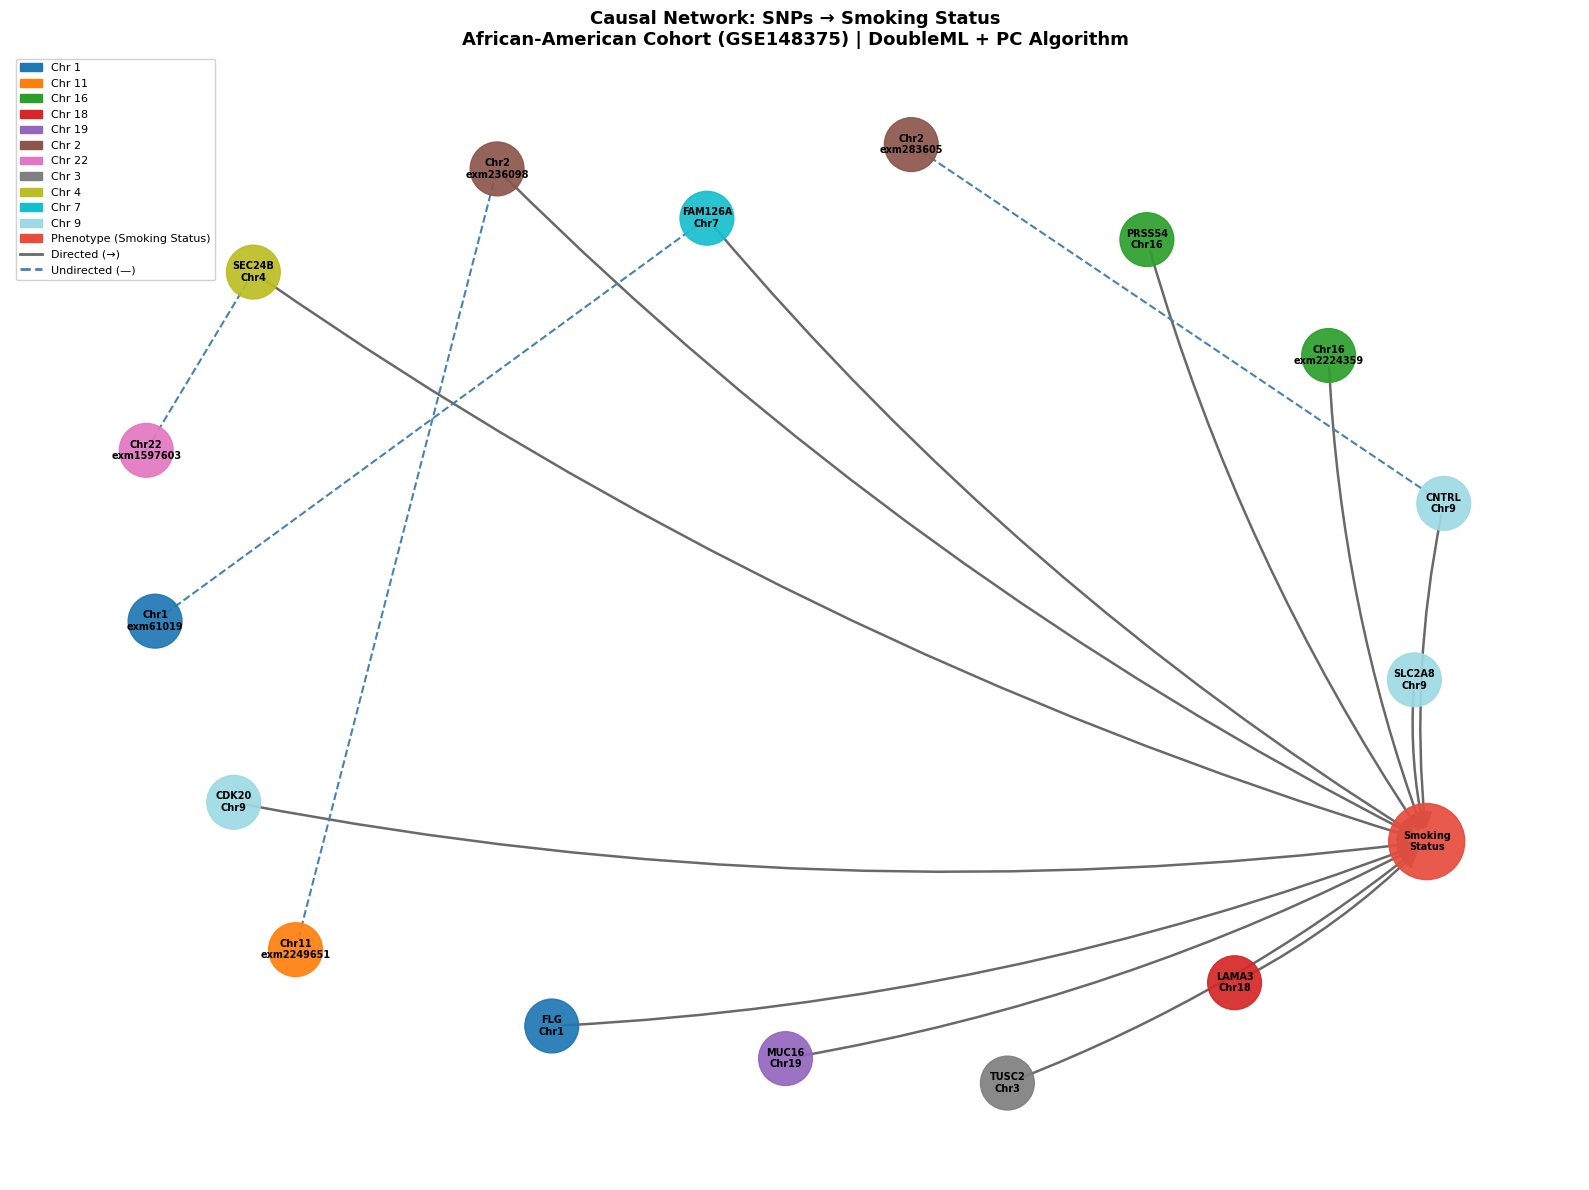

Saved: C:\Users\user\Downloads\GSE148375_clean\v2_causal_network_AA.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd
import re

# load gene annotations
annot_path = r"C:\Users\user\Downloads\GSE148375_clean\network_snp_annotations.csv"
try:
    annot_df = pd.read_csv(annot_path)
    gene_map = dict(zip(annot_df["probe_id"], annot_df["gene_annotation"]))
except:
    gene_map = {}

# chromosome lookup
manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)
manifest_df["core_name"] = manifest_df["IlmnID"].map(lambda x: re.sub(r'_\d+$', '', x))
chr_lookup = manifest_df.set_index("core_name")["Chr"]

def get_chr(pid):
    if pid == "smoking_status":
        return "phenotype"
    return str(chr_lookup.get(re.sub(r'_\d+$', '', pid), "?"))

def make_label(pid):
    if pid == "smoking_status":
        return "Smoking\nStatus"
    gene = gene_map.get(pid, "")
    chrom = get_chr(pid)
    if gene and gene not in ["intergenic", "intergenic/unknown", ""]:
        first_gene = gene.split("|")[0].strip()
        return f"{first_gene}\nChr{chrom}"
    return f"Chr{chrom}\n{pid.split('-')[0]}"

# colors
unique_chroms = sorted(set(get_chr(n) for n in G_final.nodes() if n != "smoking_status"))
cmap = plt.cm.get_cmap("tab20", len(unique_chroms))
chrom_color = {c: cmap(i) for i, c in enumerate(unique_chroms)}
chrom_color["phenotype"] = "#e74c3c"

node_colors = [chrom_color[get_chr(n)] for n in G_final.nodes()]
node_sizes = [3000 if n == "smoking_status" else 1500 for n in G_final.nodes()]
node_labels = {n: make_label(n) for n in G_final.nodes()}

# separate directed vs undirected edges
directed_edges = [
    (u, v) for u, v, d in G_final.edges(data=True)
    if not d.get("undirected")
]
undirected_pairs = set()
undirected_edges_draw = []
for u, v, d in G_final.edges(data=True):
    if d.get("undirected") and (v, u) not in undirected_pairs:
        undirected_pairs.add((u, v))
        undirected_edges_draw.append((u, v))

# draw
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G_final, seed=42, k=3.0)

nx.draw_networkx_nodes(
    G_final, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.92
)
nx.draw_networkx_labels(
    G_final, pos,
    labels=node_labels,
    font_size=7,
    font_weight="bold"
)
nx.draw_networkx_edges(
    G_final, pos,
    edgelist=directed_edges,
    edge_color="dimgray",
    arrows=True,
    arrowsize=25,
    width=1.8,
    connectionstyle="arc3,rad=0.08"
)
nx.draw_networkx_edges(
    G_final, pos,
    edgelist=undirected_edges_draw,
    edge_color="steelblue",
    arrows=False,
    style="dashed",
    width=1.5
)

# legend
legend_patches = [
    mpatches.Patch(color=chrom_color[c], label=f"Chr {c}")
    for c in unique_chroms
]
legend_patches.append(mpatches.Patch(color="#e74c3c", label="Phenotype (Smoking Status)"))
legend_patches.append(plt.Line2D([0], [0], color="dimgray", linewidth=2, label="Directed (→)"))
legend_patches.append(plt.Line2D([0], [0], color="steelblue", linewidth=2,
                                  linestyle="dashed", label="Undirected (—)"))
plt.legend(handles=legend_patches, loc="upper left", fontsize=8, framealpha=0.9)

plt.title(
    "Causal Network: SNPs → Smoking Status\n"
    "African-American Cohort (GSE148375) | DoubleML + PC Algorithm",
    fontsize=13, fontweight="bold"
)
plt.axis("off")
plt.tight_layout()

out_path = r"C:\Users\user\Downloads\GSE148375_clean\v2_causal_network_AA.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

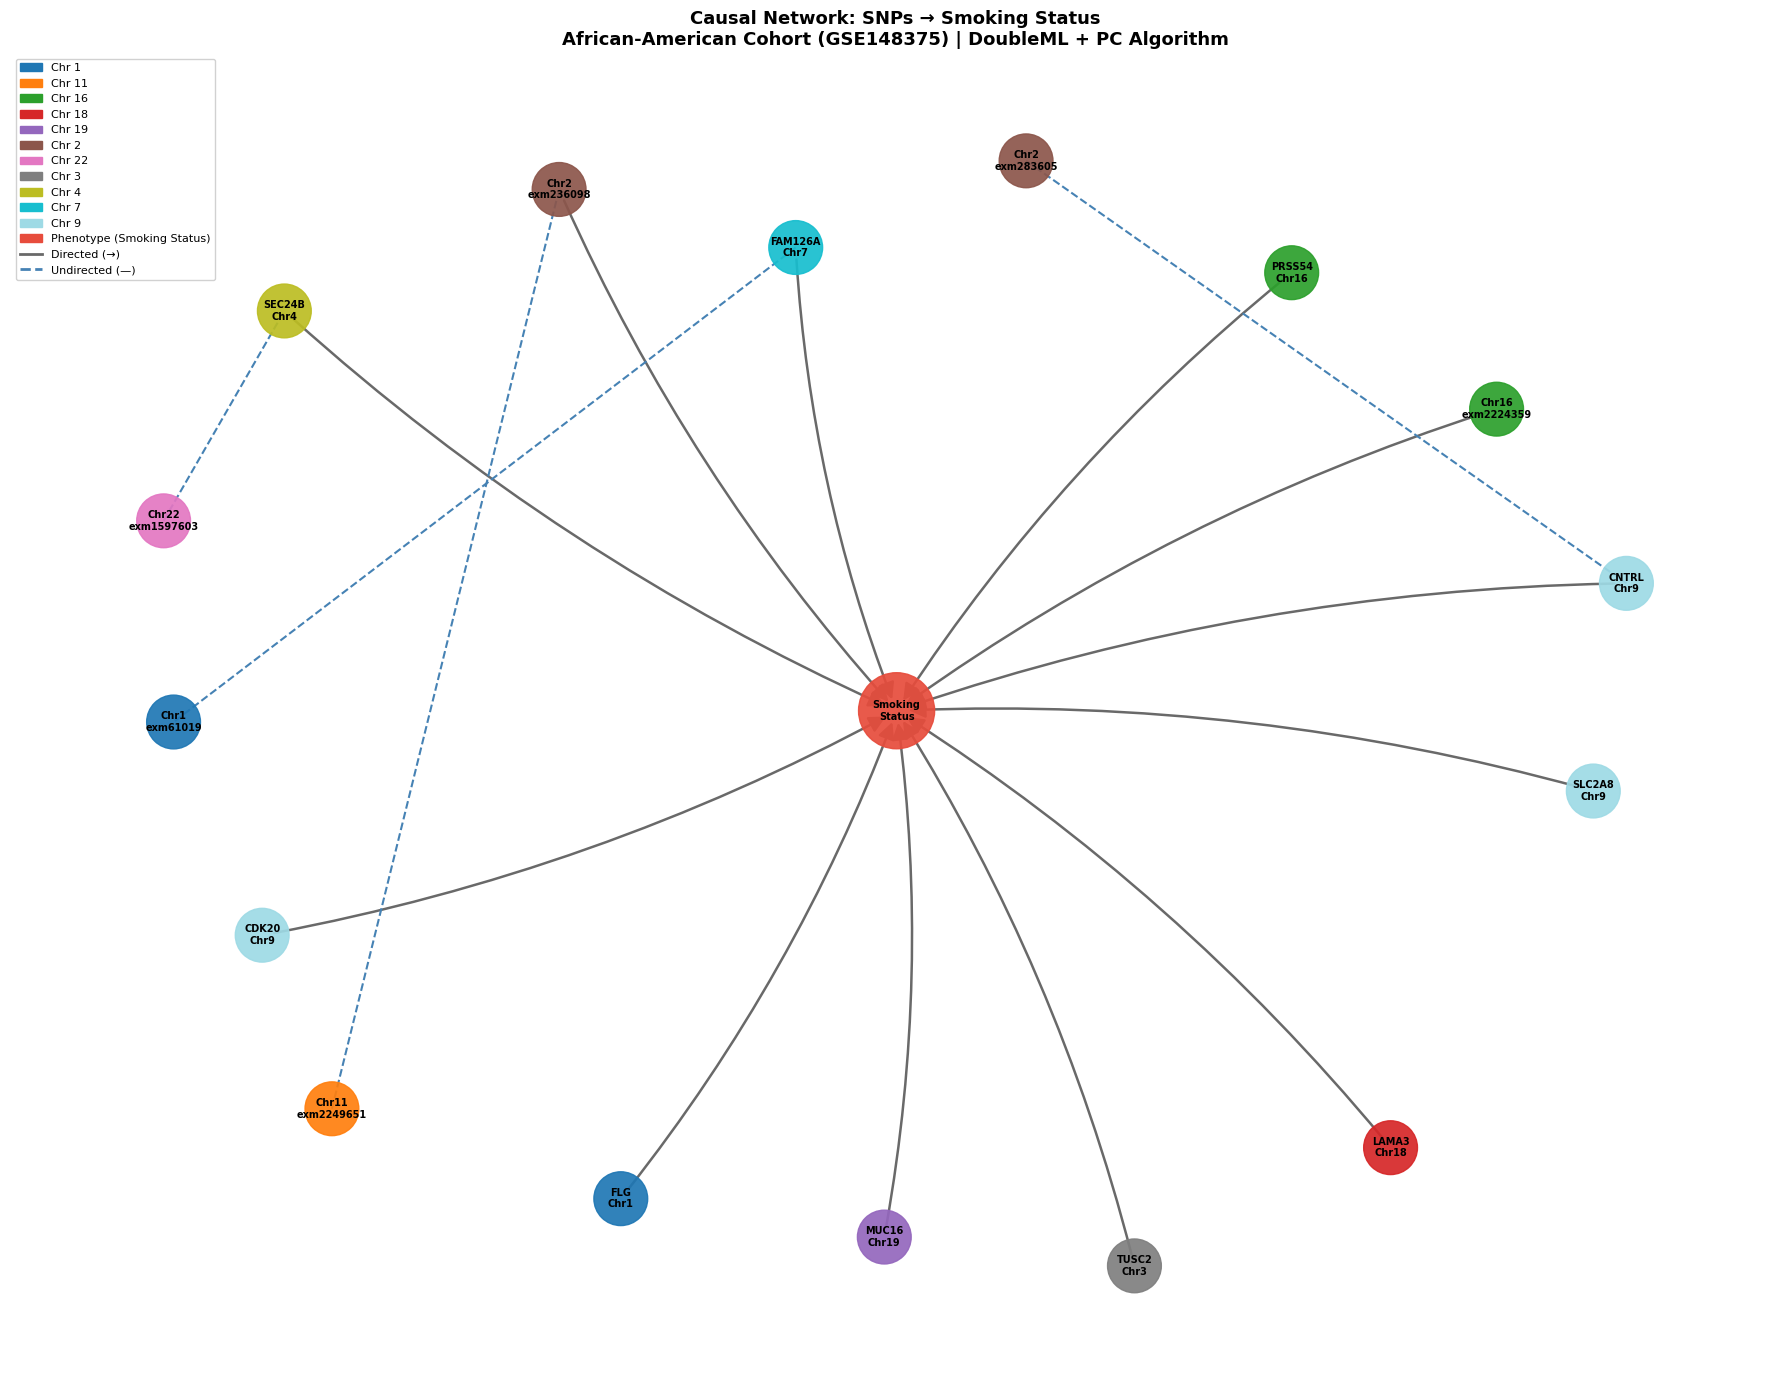

Saved: C:\Users\user\Downloads\GSE148375_clean\v2_causal_network_AA_centered.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

# fix layout: place smoking_status at center manually
pos = nx.spring_layout(G_final, seed=42, k=3.0)

# override smoking_status position to center
center = np.array([0.0, 0.0])
pos["smoking_status"] = center

# push other nodes away from center if too close
for node in pos:
    if node != "smoking_status":
        vec = pos[node] - center
        dist = np.linalg.norm(vec)
        if dist < 0.4:
            pos[node] = center + (vec / dist) * 0.4

# draw
plt.figure(figsize=(18, 14))

nx.draw_networkx_nodes(G_final, pos,
    node_color=node_colors, node_size=node_sizes, alpha=0.92)
nx.draw_networkx_labels(G_final, pos,
    labels=node_labels, font_size=7, font_weight="bold")
nx.draw_networkx_edges(G_final, pos,
    edgelist=directed_edges,
    edge_color="dimgray", arrows=True,
    arrowsize=25, width=1.8,
    connectionstyle="arc3,rad=0.08")
nx.draw_networkx_edges(G_final, pos,
    edgelist=undirected_edges_draw,
    edge_color="steelblue", arrows=False,
    style="dashed", width=1.5)

legend_patches = [mpatches.Patch(color=chrom_color[c], label=f"Chr {c}")
                  for c in unique_chroms]
legend_patches.append(mpatches.Patch(color="#e74c3c", label="Phenotype (Smoking Status)"))
legend_patches.append(plt.Line2D([0],[0], color="dimgray", linewidth=2, label="Directed (→)"))
legend_patches.append(plt.Line2D([0],[0], color="steelblue", linewidth=2,
                                  linestyle="dashed", label="Undirected (—)"))
plt.legend(handles=legend_patches, loc="upper left", fontsize=8, framealpha=0.9)

plt.title("Causal Network: SNPs → Smoking Status\n"
          "African-American Cohort (GSE148375) | DoubleML + PC Algorithm",
          fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()

out_path = r"C:\Users\user\Downloads\GSE148375_clean\v2_causal_network_AA_centered.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

In [2]:
import requests
import time
import re
import pandas as pd

# known nicotine dependence gene regions (GRCh37 coordinates)
candidate_regions = {
    "CHRNA5/CHRNA3/CHRNB4": ("15", 78_800_000, 79_100_000),
    "CYP2A6":               ("19", 41_347_000, 41_400_000),
    "CHRNA4":               ("20", 61_900_000, 62_000_000),
    "CHRNB2":               ("1",  150_991_000, 151_020_000),
    "DRD2":                 ("11", 113_270_000, 113_340_000),
    "SLC6A3":               ("5",  1_392_000,   1_445_000),
    "COMT":                 ("22", 19_929_000,  19_957_000),
}

# load our 56-SNP shortlist with positions
shortlist_pruned = pd.read_csv(r"C:\Users\user\Downloads\GSE148375_clean\v2_shortlist_ld_pruned.csv")

print("=== CANDIDATE GENE REGION CHECK ===\n")
hits = []
for gene_name, (chrom, start, end) in candidate_regions.items():
    region_hits = shortlist_pruned[
        (shortlist_pruned["Chr"].astype(str) == chrom) &
        (shortlist_pruned["MapInfo"] >= start) &
        (shortlist_pruned["MapInfo"] <= end)
    ]
    if len(region_hits) > 0:
        print(f"✓ HIT: {gene_name} (Chr{chrom}:{start:,}-{end:,})")
        for _, row in region_hits.iterrows():
            print(f"    {row['probe_id']}  pos={int(row['MapInfo']):,}  stability={row['stability_fraction']:.2f}")
        hits.extend(region_hits["probe_id"].tolist())
    else:
        print(f"✗ No hit: {gene_name} (Chr{chrom}:{start:,}-{end:,})")

print(f"\nTotal candidate gene region hits: {len(hits)}/{len(shortlist_pruned)} shortlisted SNPs")

=== CANDIDATE GENE REGION CHECK ===

✗ No hit: CHRNA5/CHRNA3/CHRNB4 (Chr15:78,800,000-79,100,000)
✗ No hit: CYP2A6 (Chr19:41,347,000-41,400,000)
✗ No hit: CHRNA4 (Chr20:61,900,000-62,000,000)
✗ No hit: CHRNB2 (Chr1:150,991,000-151,020,000)
✗ No hit: DRD2 (Chr11:113,270,000-113,340,000)
✗ No hit: SLC6A3 (Chr5:1,392,000-1,445,000)
✗ No hit: COMT (Chr22:19,929,000-19,957,000)

Total candidate gene region hits: 0/56 shortlisted SNPs


In [3]:
# check if known key SNPs are present on the chip at all
known_snps = {
    "rs16969968": ("15", 78_882_925),  # CHRNA5, strongest nicotine dependence hit
    "rs1051730":  ("15", 78_894_339),  # CHRNA3
    "rs1044396":  ("20", 61_955_361),  # CHRNA4
    "rs4833101":  ("15", 78_806_023),  # CHRNB4
    "rs2736100":  ("5",  1_286_516),   # TERT, smoking duration
    "rs3025343":  ("11", 113_288_516), # DRD2
}

manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)

print("=== KNOWN SNP PRESENCE ON CHIP ===\n")
for rsid, (chrom, pos) in known_snps.items():
    # search by position (MapInfo) and chromosome
    match = manifest_df[
        (manifest_df["Chr"].astype(str) == chrom) &
        (manifest_df["MapInfo"] == float(pos))
    ]
    # also search by name
    name_match = manifest_df[manifest_df["Name"].str.contains(rsid, na=False)]
    
    if len(match) > 0 or len(name_match) > 0:
        found = match if len(match) > 0 else name_match
        print(f"✓ PRESENT: {rsid} Chr{chrom}:{pos:,}")
        print(f"    Probe: {found['IlmnID'].values[0]}")
    else:
        print(f"✗ NOT ON CHIP: {rsid} Chr{chrom}:{pos:,}")

=== KNOWN SNP PRESENCE ON CHIP ===

✓ PRESENT: rs16969968 Chr15:78,882,925
    Probe: exm1180599-0_T_F_1922812583
✗ NOT ON CHIP: rs1051730 Chr15:78,894,339
✗ NOT ON CHIP: rs1044396 Chr20:61,955,361
✓ PRESENT: rs4833101 Chr15:78,806,023
    Probe: exm-rs8034191-131_B_F_1990485548
✗ NOT ON CHIP: rs2736100 Chr5:1,286,516
✓ PRESENT: rs3025343 Chr11:113,288,516
    Probe: exm-rs3025343-131_T_F_1990491231


In [4]:
# check if known key SNPs are present on the chip at all
known_snps = {
    "rs16969968": ("15", 78_882_925),  # CHRNA5, strongest nicotine dependence hit
    "rs1051730":  ("15", 78_894_339),  # CHRNA3
    "rs1044396":  ("20", 61_955_361),  # CHRNA4
    "rs4833101":  ("15", 78_806_023),  # CHRNB4
    "rs2736100":  ("5",  1_286_516),   # TERT, smoking duration
    "rs3025343":  ("11", 113_288_516), # DRD2
}

manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)

print("=== KNOWN SNP PRESENCE ON CHIP ===\n")
for rsid, (chrom, pos) in known_snps.items():
    # search by position (MapInfo) and chromosome
    match = manifest_df[
        (manifest_df["Chr"].astype(str) == chrom) &
        (manifest_df["MapInfo"] == float(pos))
    ]
    # also search by name
    name_match = manifest_df[manifest_df["Name"].str.contains(rsid, na=False)]
    
    if len(match) > 0 or len(name_match) > 0:
        found = match if len(match) > 0 else name_match
        print(f"✓ PRESENT: {rsid} Chr{chrom}:{pos:,}")
        print(f"    Probe: {found['IlmnID'].values[0]}")
    else:
        print(f"✗ NOT ON CHIP: {rsid} Chr{chrom}:{pos:,}")

=== KNOWN SNP PRESENCE ON CHIP ===

✓ PRESENT: rs16969968 Chr15:78,882,925
    Probe: exm1180599-0_T_F_1922812583
✗ NOT ON CHIP: rs1051730 Chr15:78,894,339
✗ NOT ON CHIP: rs1044396 Chr20:61,955,361
✓ PRESENT: rs4833101 Chr15:78,806,023
    Probe: exm-rs8034191-131_B_F_1990485548
✗ NOT ON CHIP: rs2736100 Chr5:1,286,516
✓ PRESENT: rs3025343 Chr11:113,288,516
    Probe: exm-rs3025343-131_T_F_1990491231


In [6]:
known_probes = {
    "rs16969968": "exm1180599-0_T_F_1922812583",
    "rs4833101":  "exm-rs8034191-131_B_F_1990485548",
    "rs3025343":  "exm-rs3025343-131_T_F_1990491231"
}

stability_df = pd.read_csv(r"C:\Users\user\Downloads\GSE148375_clean\v2_stability_results.csv")

print("=== KNOWN SNP STABILITY ANALYSIS ===\n")
for rsid, probe_id in known_probes.items():
    # check if in informative SNP set
    in_valid = probe_id in probe_ids_valid
    
    # check stability
    stab_row = stability_df[stability_df["probe_id"] == probe_id]
    
    if len(stab_row) > 0:
        stab = stab_row["stability_fraction"].values[0]
        n_sig = stab_row["n_significant_repeats"].values[0]
        print(f"{rsid} ({probe_id[:30]}...)")
        print(f"  In informative SNP set: {in_valid}")
        print(f"  Stability fraction: {stab:.3f} ({n_sig}/30 repeats)")
        print(f"  In final shortlist: {probe_id in shortlist_pruned['probe_id'].values}")
    else:
        print(f"{rsid}: NOT FOUND in stability results")
        print(f"  In informative SNP set: {in_valid}")
    print()

# also check their raw p-values from the single test iteration
print("=== RAW P-VALUES FROM SINGLE TEST ===")
for rsid, probe_id in known_probes.items():
    if probe_id in probe_ids_valid:
        idx = list(probe_ids_valid).index(probe_id)
        pval = pvals_test[idx]
        print(f"{rsid}: raw p = {pval:.6f}")
    else:
        print(f"{rsid}: not in informative SNP set (monomorphic/excluded)")

=== KNOWN SNP STABILITY ANALYSIS ===



NameError: name 'probe_ids_valid' is not defined